# 🐶🐱 Dog vs Cat Prediction Notebook

Download an image and classify it using a trained VGG16 model.

In [3]:
# !pip install tensorflow


In [4]:
import urllib.request
import cv2
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg16 import preprocess_input

I0000 00:00:1774115950.554664   12324 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774115950.585673   12324 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1774115951.433409   12324 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [5]:
# Download image from URL
url = "https://github.com/cookieSensei/AI-tutorials/blob/main/img.jpeg?raw=true"
file_path = "../datasets/some_image.jpg"

urllib.request.urlretrieve(url, file_path)
print("Image downloaded!")

Image downloaded!


Image shape: (318, 318, 3)


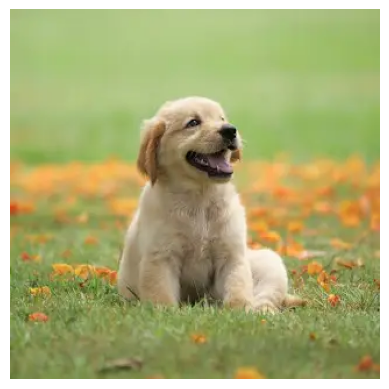

In [6]:
# Load and display image
img = cv2.imread(file_path)

print("Image shape:", img.shape)

image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis("off")
plt.show()

In [7]:
# Load your trained model
model = load_model("saved_models/vgg16_model.h5")
print("Model loaded!")

I0000 00:00:1774115961.571701   12324 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10105 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model loaded!


In [8]:
# Preprocess image for VGG16
IMG_SIZE = (160, 160)

img_resized = cv2.resize(img, IMG_SIZE)
img_array = preprocess_input(img_resized)
img_array = np.expand_dims(img_array, axis=0)

print("Prepared input shape:", img_array.shape)

Prepared input shape: (1, 160, 160, 3)


In [9]:
# Predict
prediction = model.predict(img_array)[0][0]

print("Raw output:", prediction)

if prediction > 0.5:
    print("Prediction: Dog 🐶")
else:
    print("Prediction: Cat 🐱")

I0000 00:00:1774115965.668773   13249 service.cc:153] XLA service 0x7e5518043520 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774115965.668788   13249 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3060, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.8.0; Toolkit: 12.5.0; DNN: 9.10.2)
I0000 00:00:1774115965.674176   13249 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1774115965.725512   13249 cuda_dnn.cc:461] Loaded cuDNN version 91002


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Raw output: 1.0
Prediction: Dog 🐶


I0000 00:00:1774115968.010155   13249 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
